In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
import numpy as np
from scipy import stats
import os
from pathlib import Path

# Set the style for plots
sns.set_palette("deep")

In [2]:
WD_PATH = Path(f"{os.getcwd()}")
print(WD_PATH)
CONTROL_PATH = Path('/home/awelch/GIPL/control_stable_yr')

/home/awelch/GIPL/O_warming_experiment


<h1>Analysis of Daily Data</h1>

In [3]:
# Load control and experimental data
control_data_daily = np.loadtxt(CONTROL_PATH/'out/result.txt', skiprows=0, unpack=False)
experimental_data_daily = np.loadtxt(WD_PATH/'stable_yr/out/result.txt', skiprows=0,  unpack=False)

# Convert to pd data frame
control_df_daily = pd.DataFrame(control_data_daily, columns=['id', 'time', 'Tair', 'snow', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m'])
experimental_df_daily = pd.DataFrame(experimental_data_daily, columns = ['id', 'time', 'Tair', 'snow', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m'])

# Select needed columns
# Select 2nd column (index 1) and columns 5-11 (indices 4-10)
control_df_daily = control_df_daily.iloc[:, [1] + list(range(4, 11))]
experimental_df_daily = experimental_df_daily.iloc[:, [1] + list(range(4, 11))]
print(control_df_daily.head())

# # Set 'year' as the index
control_df_daily.set_index('time', inplace=True)
experimental_df_daily.set_index('time', inplace=True)

   time     0.01m     0.08m     0.13m     0.24m     0.38m     0.53m     0.67m
0   1.0 -9.252666 -8.285000 -7.752000 -7.429000 -6.909000 -6.581000 -6.293000
1   2.0 -8.527715 -8.043407 -7.703405 -7.468260 -7.053283 -6.807103 -6.623608
2   3.0 -8.387612 -7.954930 -7.665329 -7.471799 -7.135360 -6.927766 -6.760367
3   4.0 -8.220553 -7.879320 -7.639852 -7.476766 -7.187491 -7.003717 -6.849771
4   5.0 -8.028191 -7.767278 -7.584016 -7.454775 -7.213367 -7.052298 -6.912105


<h2>Calculate Year Thawing and Freezing Degree Days in Experimental and Control Runs</h2>

In [4]:
def calculate_year_from_index(df):
    # Calculate the year based on the index (assuming daily data)
    return ((df.index - df.index[0]) // 365 + 1).astype(int)

def calculate_thawing_freezing_days(data, depth):
    # Create a copy of the data to avoid modifying the original dataframe
    df_copy = data.copy()

    # Calculate the year column from the index
    df_copy['year'] = calculate_year_from_index(df_copy)

    thawing_days = []
    freezing_days = []

    # Iterate through each year in the data
    for year in range(df_copy['year'].min(), df_copy['year'].max() + 1):
        year_data = df_copy[df_copy['year'] == year][depth]  # Filter data for the specific year
        thawing = (year_data > 0).sum()  # Count days where temperature > 0
        freezing = (year_data < 0).sum()  # Count days where temperature < 0
        thawing_days.append(thawing)
        freezing_days.append(freezing)

    return thawing_days, freezing_days

In [5]:
# Calculate thawing and freezing days for control and experimental data
depths = ['0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']

# Assuming the dataframes have daily time steps, we'll calculate the year dynamically
def calculate_year_from_index(df):
    return ((df.index - df.index[0]) // 365 + 1).astype(int)

for depth in depths:
    print(f'---------------------{depth}---------------------')

    # Calculate thawing and freezing days for control and experimental data
    control_thawing, control_freezing = calculate_thawing_freezing_days(control_df_daily, depth)
    exp_thawing, exp_freezing = calculate_thawing_freezing_days(experimental_df_daily, depth)

    # Dynamically calculate the 'year' column for control and experimental data
    control_years = calculate_year_from_index(control_df_daily)
    exp_years = calculate_year_from_index(experimental_df_daily)

    # Print results for control data
    print("Control:")
    for year, (thawing, freezing) in enumerate(zip(control_thawing, control_freezing), start=control_years.min()):
        print(f"Year {year}: Thawing {thawing:.2f} days, Freezing {freezing:.2f} days")

    # Print results for experimental data
    print("\nExperimental:")
    for year, (thawing, freezing) in enumerate(zip(exp_thawing, exp_freezing), start=exp_years.min()):
        print(f"Year {year}: Thawing {thawing:.2f} days, Freezing {freezing:.2f} days")

    print("\n")

print("Analysis complete.")

---------------------0.01m---------------------
Control:
Year 1: Thawing 125.00 days, Freezing 240.00 days

Experimental:
Year 1: Thawing 135.00 days, Freezing 230.00 days


---------------------0.08m---------------------
Control:
Year 1: Thawing 114.00 days, Freezing 251.00 days

Experimental:
Year 1: Thawing 126.00 days, Freezing 239.00 days


---------------------0.13m---------------------
Control:
Year 1: Thawing 92.00 days, Freezing 273.00 days

Experimental:
Year 1: Thawing 120.00 days, Freezing 245.00 days


---------------------0.24m---------------------
Control:
Year 1: Thawing 88.00 days, Freezing 277.00 days

Experimental:
Year 1: Thawing 105.00 days, Freezing 260.00 days


---------------------0.38m---------------------
Control:
Year 1: Thawing 65.00 days, Freezing 300.00 days

Experimental:
Year 1: Thawing 123.00 days, Freezing 242.00 days


---------------------0.53m---------------------
Control:
Year 1: Thawing 0.00 days, Freezing 365.00 days

Experimental:
Year 1: Thawi

<h2>Plot Experimental and Control Ground Temperatures at Each Depth</h2>

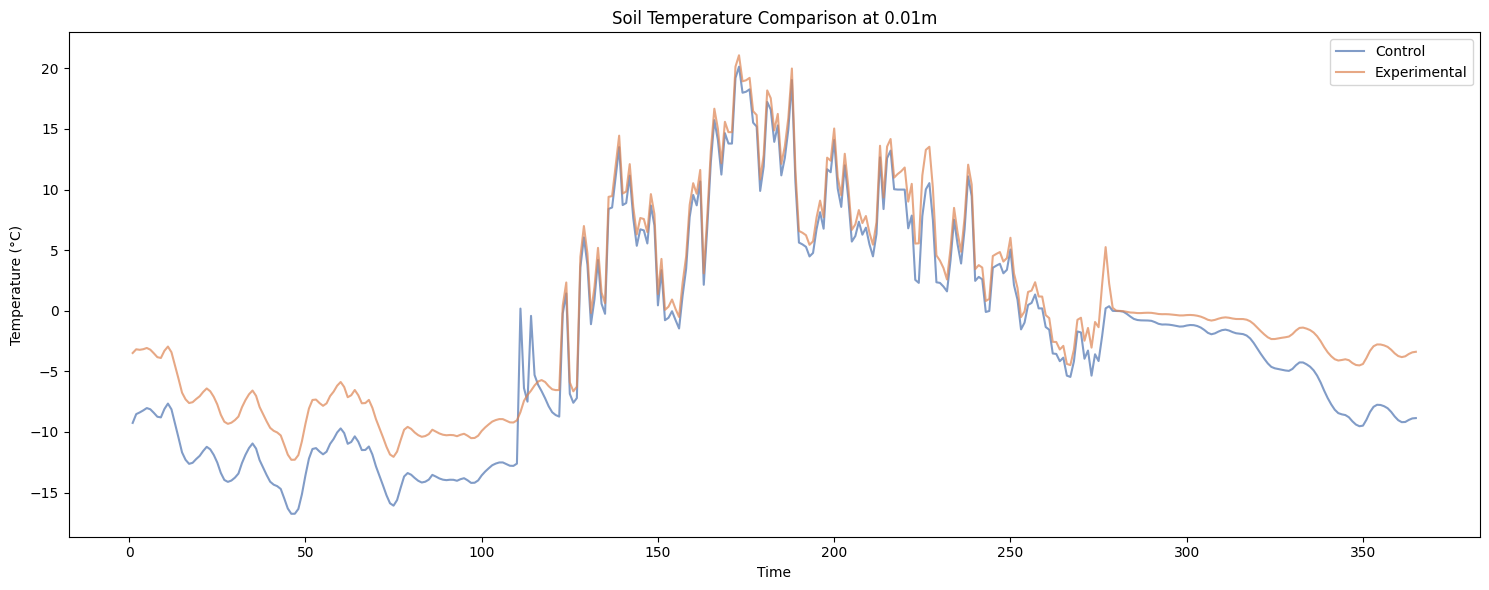

Statistics for 0.01m:
Control mean temperature: -2.54°C
Experimental mean temperature: -0.19°C
Temperature difference: 2.35°C
T-statistic: -3.7642
P-value: 0.0002




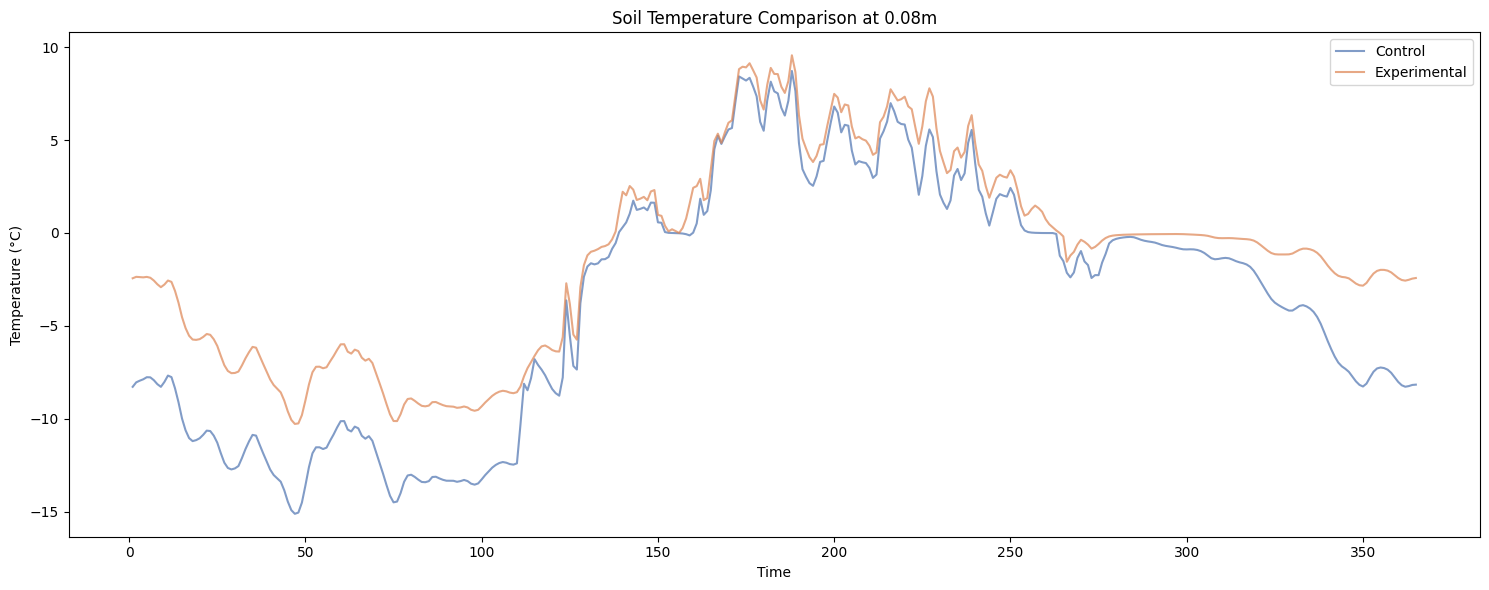

Statistics for 0.08m:
Control mean temperature: -3.74°C
Experimental mean temperature: -1.24°C
Temperature difference: 2.50°C
T-statistic: -5.6549
P-value: 0.0000




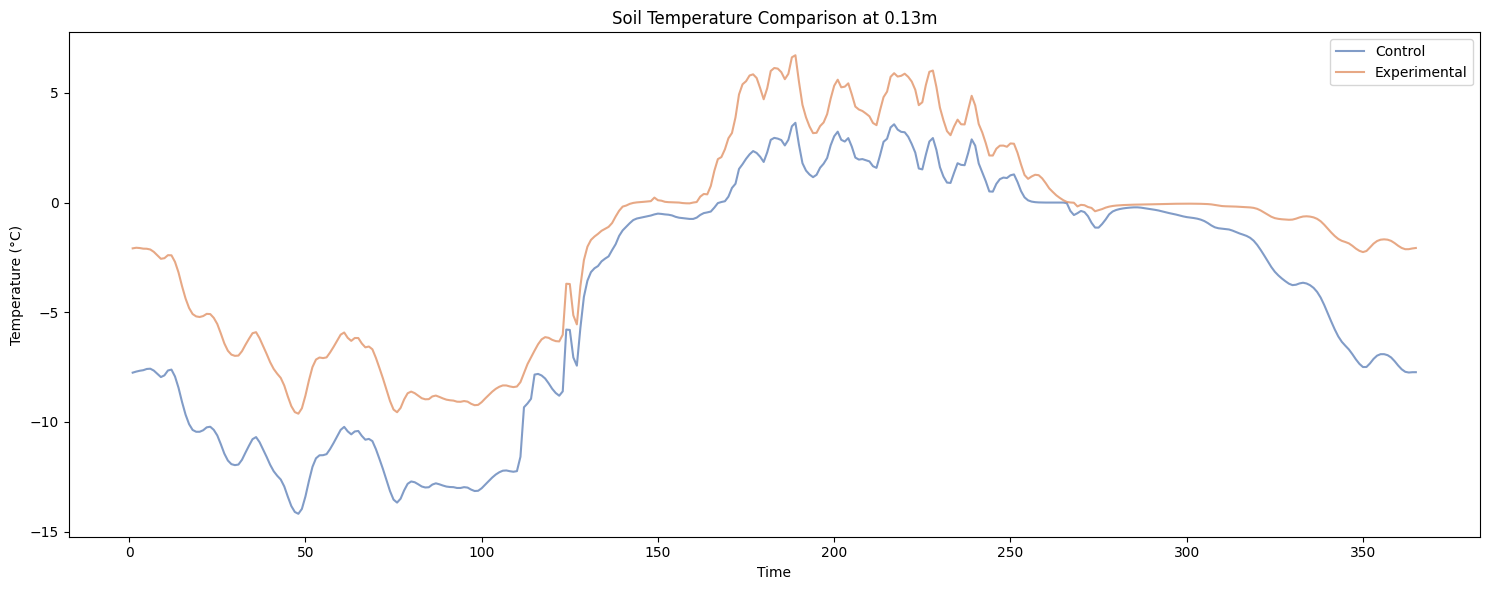

Statistics for 0.13m:
Control mean temperature: -4.30°C
Experimental mean temperature: -1.53°C
Temperature difference: 2.76°C
T-statistic: -7.3500
P-value: 0.0000




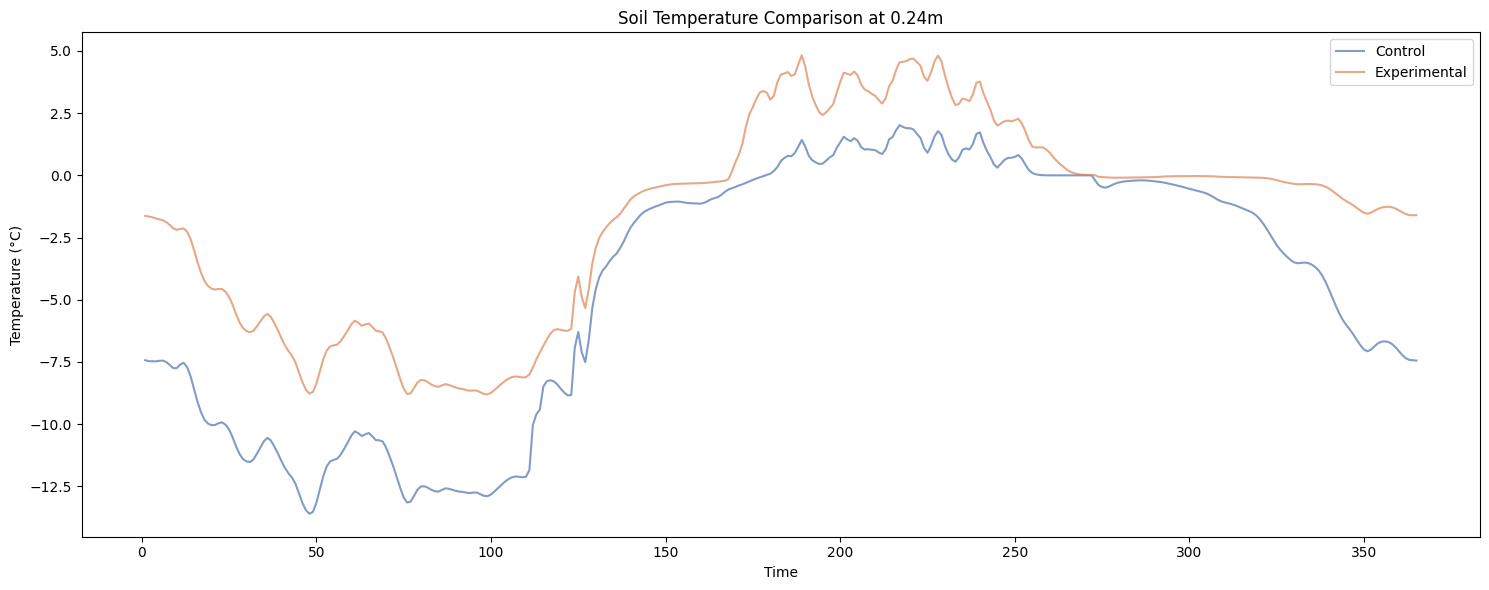

Statistics for 0.24m:
Control mean temperature: -4.50°C
Experimental mean temperature: -1.66°C
Temperature difference: 2.84°C
T-statistic: -8.3150
P-value: 0.0000




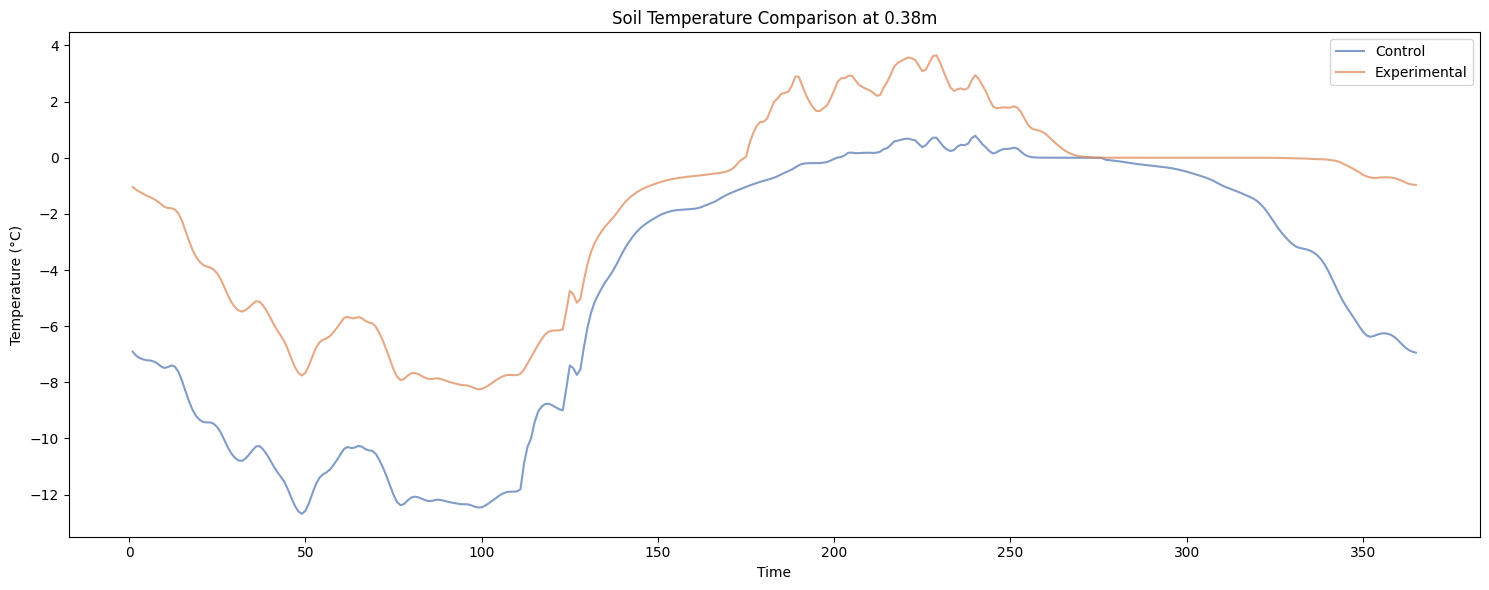

Statistics for 0.38m:
Control mean temperature: -4.63°C
Experimental mean temperature: -1.72°C
Temperature difference: 2.91°C
T-statistic: -9.4269
P-value: 0.0000




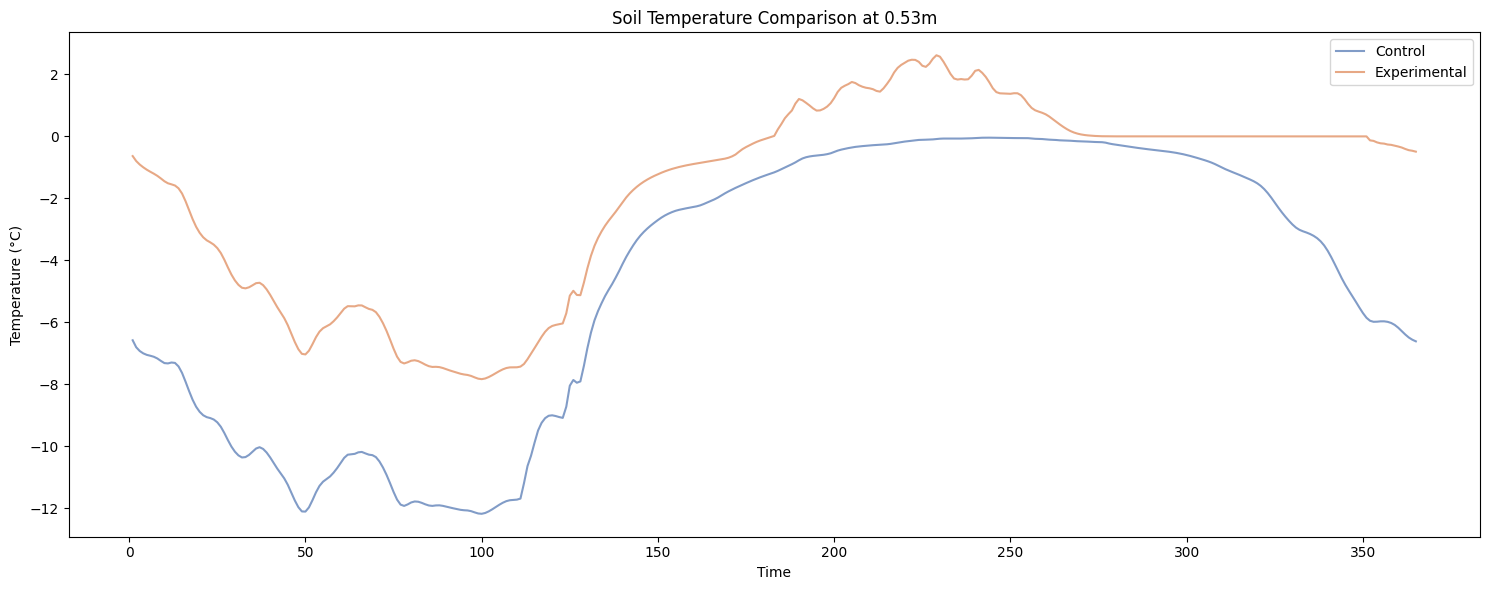

Statistics for 0.53m:
Control mean temperature: -4.73°C
Experimental mean temperature: -1.81°C
Temperature difference: 2.92°C
T-statistic: -10.1851
P-value: 0.0000




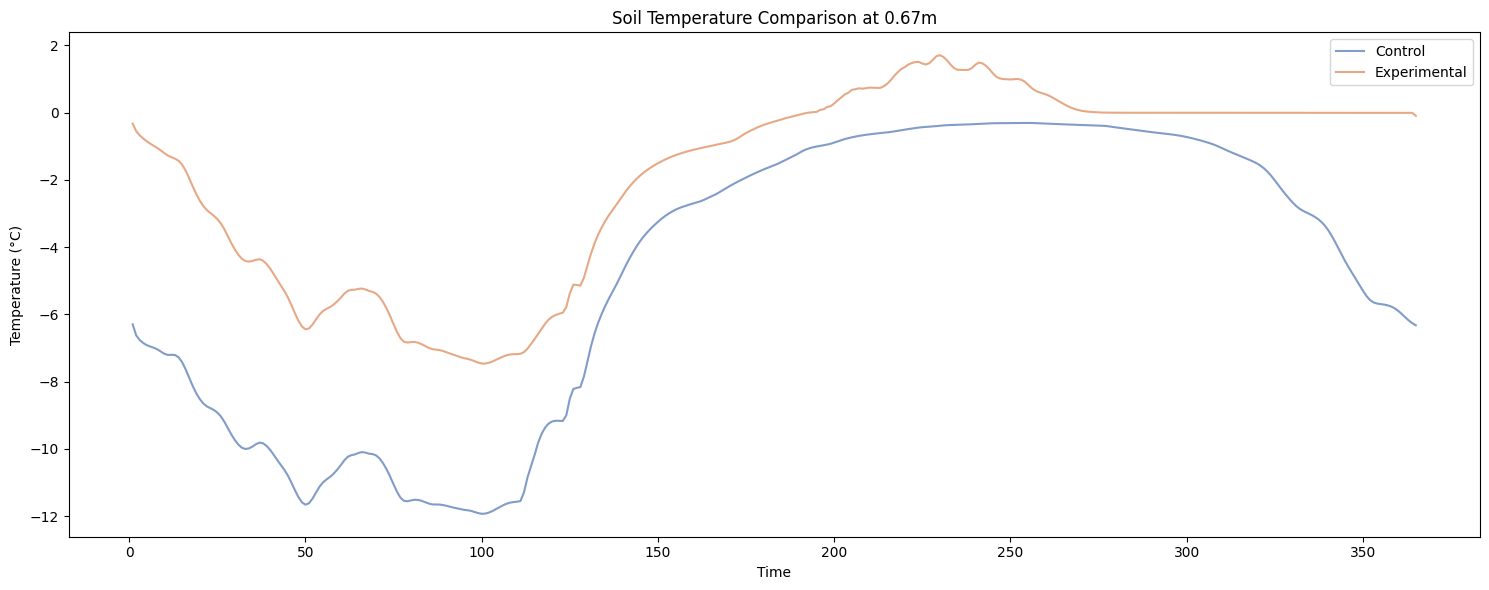

Statistics for 0.67m:
Control mean temperature: -4.79°C
Experimental mean temperature: -1.87°C
Temperature difference: 2.92°C
T-statistic: -10.8654
P-value: 0.0000




In [6]:
def plot_comparison(depth):
    plt.figure(figsize=(15, 6))
    plt.plot(control_df_daily.index, control_df_daily[depth], label='Control', alpha=0.7)
    plt.plot(experimental_df_daily.index, experimental_df_daily[depth], label='Experimental', alpha=0.7)
    plt.title(f'Soil Temperature Comparison at {depth}')
    plt.xlabel('Time')
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    # plt.savefig(f'comparison_{depth}.png')
    # plt.close()

    # Calculate and print statistics
    control_mean = control_df_daily[depth].mean()
    exp_mean = experimental_df_daily[depth].mean()
    temp_diff = exp_mean - control_mean
    t_stat, p_value = stats.ttest_ind(control_df_daily[depth], experimental_df_daily[depth])
    
    print(f"Statistics for {depth}:")
    print(f"Control mean temperature: {control_mean:.2f}°C")
    print(f"Experimental mean temperature: {exp_mean:.2f}°C")
    print(f"Temperature difference: {temp_diff:.2f}°C")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    print("\n")

# Plot comparisons for each depth
for depth in depths:
    plot_comparison(depth)

<h2>Contour Plot (Analyze Active Layer)</h2>

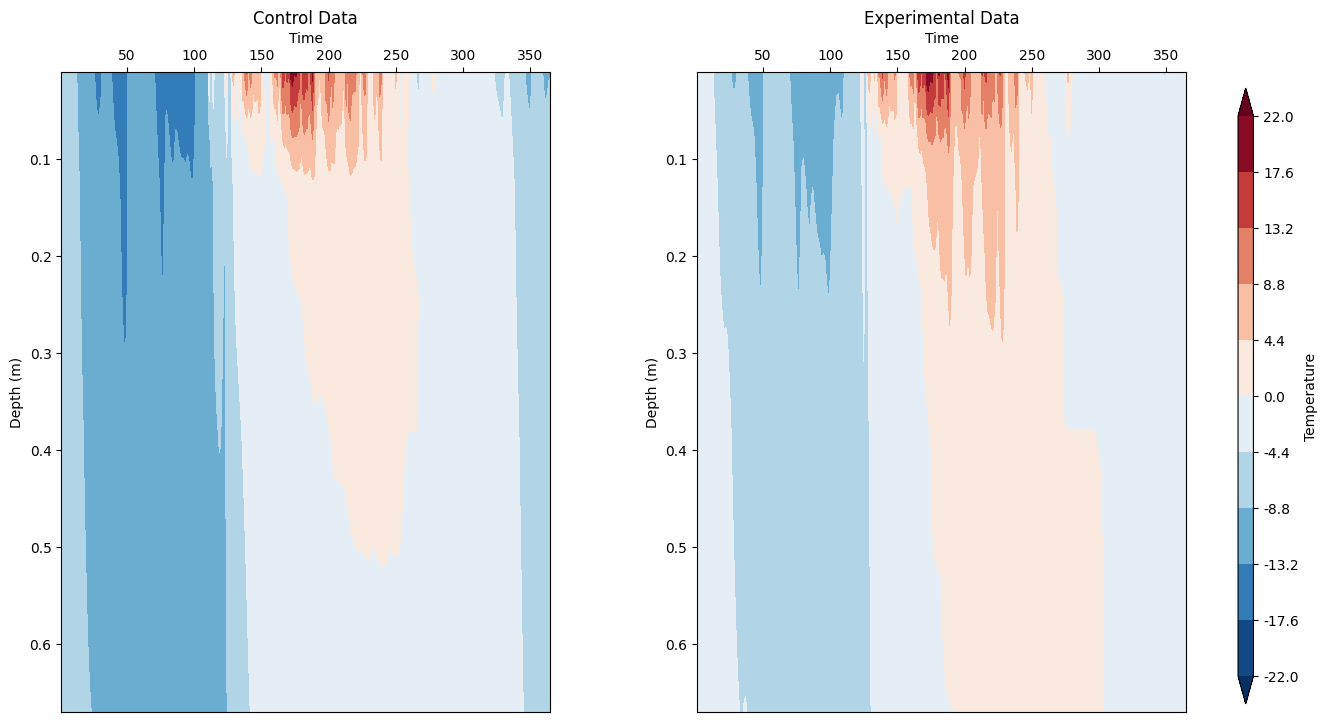

In [7]:
# Define the actual depth values
depths = np.array([0.01, 0.08, 0.13, 0.24, 0.38, 0.53, 0.67])

# Create a figure with 1 row and 2 columns for side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

# Calculate global vmin and vmax for both DataFrames
all_data = np.concatenate((control_df_daily.values.flatten(), experimental_df_daily.values.flatten()))
abs_max = max(abs(np.floor(np.min(all_data))), abs(np.ceil(np.max(all_data))))
vmin, vmax = -abs_max, abs_max

# Create rounded levels for the contour plot
levels = np.linspace(vmin, vmax, 11)  # 11 levels for 10 color divisions

# Create a meshgrid for plotting
times = control_df_daily.index.values
X, Y = np.meshgrid(times, depths)

# Create a normalization that's centered on 0
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# First contour plot for control_df_daily
contour1 = ax[0].contourf(X, Y, control_df_daily.values.T, 
                          levels=levels, cmap='RdBu_r', norm=norm, extend='both')

# Second contour plot for experimental_df_daily
contour2 = ax[1].contourf(X, Y, experimental_df_daily.values.T, 
                          levels=levels, cmap='RdBu_r', norm=norm, extend='both')

# Customize both subplots
for i in range(2):
    ax[i].set_ylim(depths.max(), depths.min())  # Invert y-axis
    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('Depth (m)')
    ax[i].xaxis.set_ticks_position('top')
    ax[i].xaxis.set_label_position('top')

# Set titles
ax[0].set_title('Control Data')
ax[1].set_title('Experimental Data')

# Add a color bar for both plots
cbar = fig.colorbar(contour1, ax=ax, orientation='vertical', fraction=0.02, pad=0.04, aspect=40)
cbar.set_label('Temperature')  # Optional label for the color bar

# Set color bar ticks to match the levels
cbar.set_ticks(levels)
cbar.set_ticklabels([f'{level:.1f}' for level in levels])

# Manually adjust layout to prevent overlap
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1, wspace=0.3)  # Adjust spacing as needed

# Adjust layout
plt.show()

<h1>Analysis of Year Mean Data</h1>

In [8]:
# Load control and experimental data using read_fwf
control_data = pd.read_fwf(CONTROL_PATH/'out/mean.txt', header=None)
experimental_data = pd.read_fwf(WD_PATH/'stable_yr/out/mean.txt', header=None)

# print(control_data.shape)
# print(control_data.head())

# Select needed columns (2nd column and columns 5-11)
control_df = control_data.iloc[:, [1] + list(range(4, 11))]
control_df.columns = ['time', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']
experimental_df = experimental_data.iloc[:, [1] + list(range(4, 11))]
experimental_df.columns = ['time', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']

print(control_df.head())
print(experimental_df.head())


    time  0.01m  0.08m  0.13m  0.24m  0.38m  0.53m  0.67m
0  183.0 -2.545 -3.741 -4.296   -4.5 -4.631 -4.726 -4.793
    time  0.01m  0.08m  0.13m  0.24m  0.38m  0.53m  0.67m
0  183.0 -0.194 -1.244 -1.532 -1.657 -1.718 -1.809 -1.873


In [9]:
# Assuming the data has columns: 'time', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m'
depths = ['0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']

# Create a new 'year' column assigning years 1 to 10
control_df = control_df.copy()  # Ensures we're working on a full DataFrame copy
experimental_df = experimental_df.copy()

control_df.loc[:, 'year'] = 1  # Use .loc to assign values explicitly
experimental_df.loc[:, 'year'] = 1

# Set 'year' as the index
control_df.set_index('year', inplace=True)
experimental_df.set_index('year', inplace=True)

print(control_df.head())
print(experimental_df.head())

       time  0.01m  0.08m  0.13m  0.24m  0.38m  0.53m  0.67m
year                                                        
1     183.0 -2.545 -3.741 -4.296   -4.5 -4.631 -4.726 -4.793
       time  0.01m  0.08m  0.13m  0.24m  0.38m  0.53m  0.67m
year                                                        
1     183.0 -0.194 -1.244 -1.532 -1.657 -1.718 -1.809 -1.873


<h2>Plot Difference in Ground Temperature at Each Depth</h2>

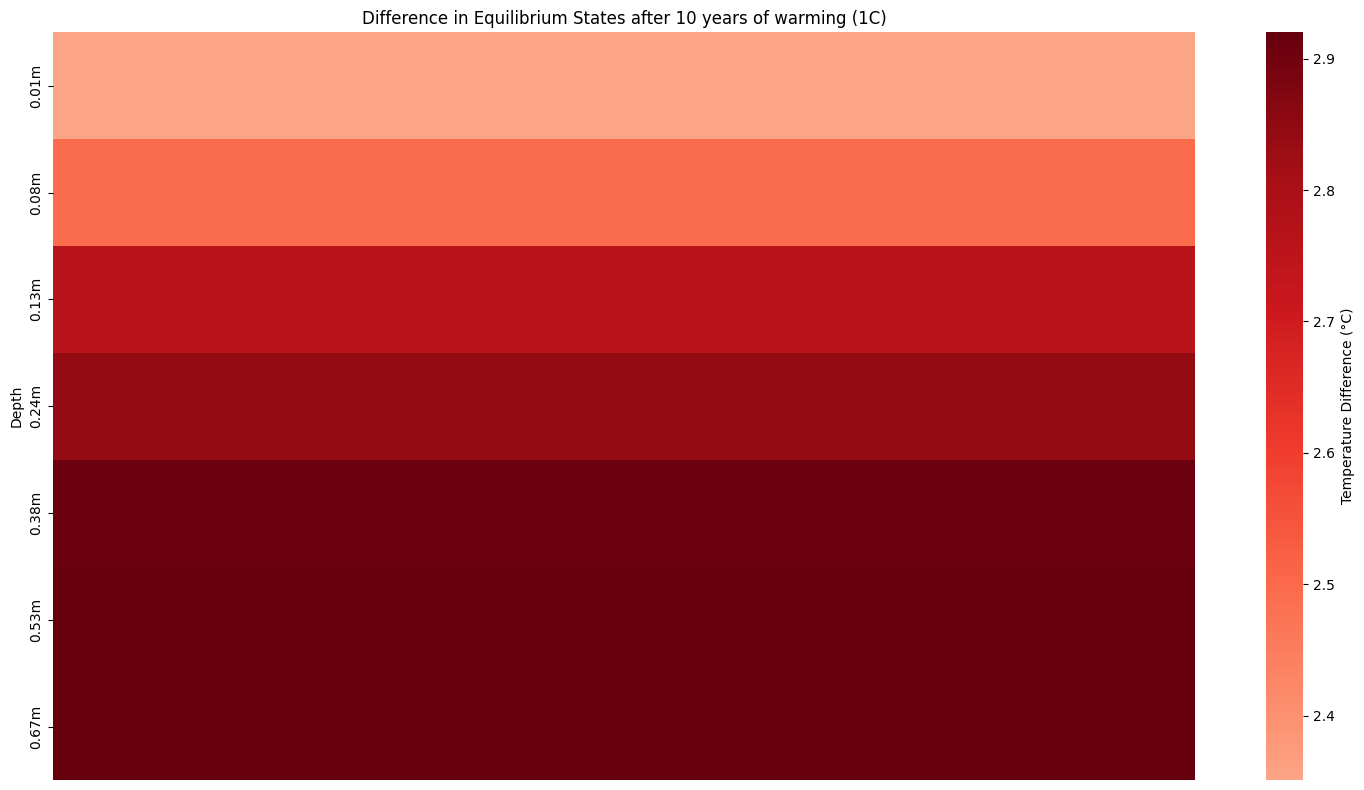

In [11]:
# Function to plot temperature difference heatmap
def plot_heatmap():
    # Calculate temperature differences
    diff_data = experimental_df[depths].values - control_df[depths].values

    # Create a heatmap of temperature differences
    plt.figure(figsize=(15, 8))
    sns.heatmap(diff_data.T, cmap='Reds', center=2.5, cbar_kws={'label': 'Temperature Difference (°C)'}, 
                yticklabels=depths, xticklabels=control_df.index)
    plt.title('Difference in Equilibrium States after 10 years of warming (1C)')
    plt.xlabel('')
    plt.ylabel('Depth')

    # Remove the x-ticks
    plt.xticks([], [])
    
    plt.tight_layout()
    plt.show()
    # Optionally save the heatmap
    # plt.savefig('temperature_difference_heatmap.png')
    # plt.close()

# Call the heatmap plotting function
plot_heatmap()

<h2>Calculate Control and Warming Thermal Offsets</h2>

In [12]:
def determine_thermal_offset(depth):
    print(f'--------------{depth}--------------')
    control_offset = (control_df['0.01m'] - control_df[depth]).values
    print(f'Control Thermal offset: {control_offset[0]}')
    
    experimental_offset = (experimental_df['0.01m'] - experimental_df[depth]).values
    print(f'Experimental Thermal offset: {experimental_offset[0]}')

    delta = control_offset - experimental_offset
    print(f'Difference: {delta[0]}\n')


depths = ['0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']
for depth in depths:
    determine_thermal_offset(depth)
    

--------------0.01m--------------
Control Thermal offset: 0.0
Experimental Thermal offset: 0.0
Difference: 0.0

--------------0.08m--------------
Control Thermal offset: 1.1960000000000002
Experimental Thermal offset: 1.05
Difference: 0.14600000000000013

--------------0.13m--------------
Control Thermal offset: 1.7510000000000003
Experimental Thermal offset: 1.338
Difference: 0.41300000000000026

--------------0.24m--------------
Control Thermal offset: 1.955
Experimental Thermal offset: 1.463
Difference: 0.492

--------------0.38m--------------
Control Thermal offset: 2.0860000000000003
Experimental Thermal offset: 1.524
Difference: 0.5620000000000003

--------------0.53m--------------
Control Thermal offset: 2.181
Experimental Thermal offset: 1.615
Difference: 0.5660000000000001

--------------0.67m--------------
Control Thermal offset: 2.248
Experimental Thermal offset: 1.679
Difference: 0.5690000000000002

